In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../working/case_64x64_forKraken/01_bitmaps/topologies_8x8.csv')

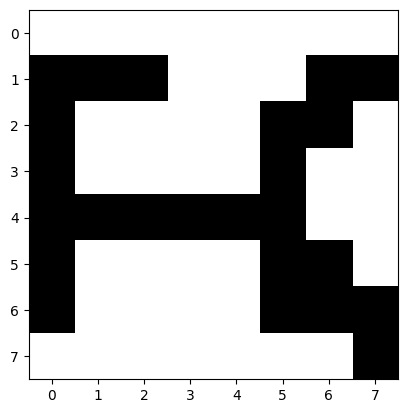

In [3]:
# visualize first row
plt.imshow(df.iloc[0].values.reshape(8, 8), cmap='gray')

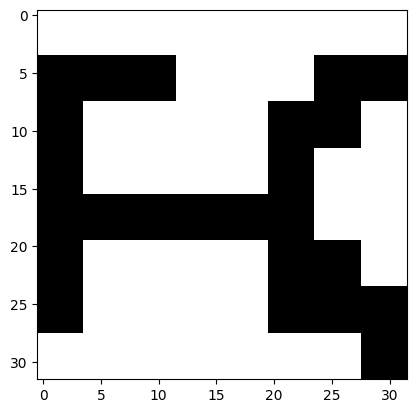

In [4]:
# Double the resolution by scaling each pixel to a NxN block
N = 4
def scale_bitmap(bitmap, N):
    bitmap_2d = bitmap.values.reshape(8, 8)
    scaled_bitmap = bitmap_2d.repeat(N, axis=0).repeat(N, axis=1)
    return scaled_bitmap

scaled_bitmap = scale_bitmap(df.iloc[0], N)
plt.imshow(scaled_bitmap, cmap='gray')

In [5]:
scaled_bitmap.shape

(32, 32)

In [6]:
# Save scaled bitmaps to new CSV
scaled_bitmaps = df.apply(lambda row: scale_bitmap(row, N).flatten(), axis=1)
scaled_bitmaps_df = pd.DataFrame(scaled_bitmaps.tolist())
scaled_bitmaps_df.to_csv('../working/topologies_32x32_upscaled_x4.csv', index=False, header=False)